In [1]:
!pip install gensim python-crfsuite fasttext flashtext && pip install hazm --no-deps

  Using cached gensim-4.4.0-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (8.4 kB)
  Using cached python_crfsuite-0.9.11-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.3 kB)
  Using cached fasttext-0.9.3.tar.gz (73 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached flashtext-2.7.tar.gz (14 kB)
  Preparing metadata (setup.py) ... done
  Using cached pybind11-3.0.1-py3-none-any.whl.metadata (10.0 kB)
Using cached gensim-4.4.0-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (27.9 MB)
Using cached python_crfsuite-0.9.11-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (1.3 MB)
Using cached pybind11-3.0.1-py3-none-any.whl (293 kB)
  Created wheel for fasttext: filename=fasttext-0.9.3-cp312-cp312-linux_x86_64.whl size=4498205 sha256=eac23c7b9156d53b2703f2c37c8992457157c16c7f19f15ede0d01435aaa8a07
  Stored in directory: /ro

In [5]:
from hazm import Normalizer, word_tokenize, sent_tokenize
from gensim.models import Word2Vec
import matplotlib.pyplot as plt
import numpy as np

In [6]:
text = """
پردازش زبان طبیعی یکی از شاخه‌های مهم هوش مصنوعی است.
امروزه یادگیری ماشین و شبکه‌های عصبی در بسیاری از کاربردهای زبان استفاده می‌شوند.
مدل‌های وُرد۲وِک می‌توانند معنای کلمات را در قالب بردارهای عددی نمایش دهند.
کاربردهای این مدل شامل تحلیل احساسات، جستجوی معنایی، ترجمه ماشینی و چت‌بات‌ها است.
"""

print(text)


پردازش زبان طبیعی یکی از شاخه‌های مهم هوش مصنوعی است.
امروزه یادگیری ماشین و شبکه‌های عصبی در بسیاری از کاربردهای زبان استفاده می‌شوند.
مدل‌های وُرد۲وِک می‌توانند معنای کلمات را در قالب بردارهای عددی نمایش دهند.
کاربردهای این مدل شامل تحلیل احساسات، جستجوی معنایی، ترجمه ماشینی و چت‌بات‌ها است.



In [7]:
normalizer = Normalizer()

def clean_text(text):
    text = normalizer.normalize(text)
    text = text.replace("‌", " ")  # remove zero-width non-joiner
    text = text.replace("\n", " ") # remove line breaks
    text = ''.join(ch for ch in text if not ch.isdigit())  # remove digits
    return text

cleaned = clean_text(text)
print(cleaned)

 پردازش زبان طبیعی یکی از شاخه های مهم هوش مصنوعی است.  امروزه یادگیری ماشین و شبکه های عصبی در بسیاری از کاربردهای زبان استفاده می شوند.  مدل های ورد  وک می توانند معنای کلمات را در قالب بردارهای عددی نمایش دهند.  کاربردهای این مدل شامل تحلیل احساسات، جستجوی معنایی، ترجمه ماشینی و چت بات ها است.  


In [9]:
sentences = sent_tokenize(cleaned)
sentences
tokenized = [word_tokenize(sent) for sent in sentences]
tokenized

[['پردازش',
  'زبان',
  'طبیعی',
  'یکی',
  'از',
  'شاخه',
  'های',
  'مهم',
  'هوش',
  'مصنوعی',
  'است',
  '.'],
 ['امروزه',
  'یادگیری',
  'ماشین',
  'و',
  'شبکه',
  'های',
  'عصبی',
  'در',
  'بسیاری',
  'از',
  'کاربردهای',
  'زبان',
  'استفاده',
  'می',
  'شوند',
  '.'],
 ['مدل',
  'های',
  'ورد',
  'وک',
  'می',
  'توانند',
  'معنای',
  'کلمات',
  'را',
  'در',
  'قالب',
  'بردارهای',
  'عددی',
  'نمایش',
  'دهند',
  '.'],
 ['کاربردهای',
  'این',
  'مدل',
  'شامل',
  'تحلیل',
  'احساسات',
  '،',
  'جستجوی',
  'معنایی',
  '،',
  'ترجمه',
  'ماشینی',
  'و',
  'چت',
  'بات',
  'ها',
  'است',
  '.']]

In [10]:
model_sg = Word2Vec(
    tokenized,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    sg=1  # skip-gram
)

In [11]:
model_cbow = Word2Vec(
    tokenized,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    sg=0  # CBOW
)

In [12]:
word = "زبان"

print("Skip-Gram:", model_sg.wv.most_similar(word))
print("CBOW:", model_cbow.wv.most_similar(word))

Skip-Gram: [('مهم', 0.26842641830444336), ('بسیاری', 0.14292645454406738), ('بات', 0.12818211317062378), ('ها', 0.11057380586862564), ('و', 0.10896483063697815), ('نمایش', 0.10811354219913483), ('عددی', 0.10141533613204956), ('دهند', 0.09939516335725784), ('جستجوی', 0.09688881039619446), ('تحلیل', 0.08632347732782364)]
CBOW: [('مهم', 0.26884031295776367), ('بسیاری', 0.143144428730011), ('بات', 0.1284506469964981), ('ها', 0.11002267152070999), ('و', 0.1088898554444313), ('نمایش', 0.10835204273462296), ('عددی', 0.10193564742803574), ('دهند', 0.09931378811597824), ('جستجوی', 0.09624310582876205), ('تحلیل', 0.08637616783380508)]


In [13]:
words = ["زبان", "هوش", "ماشین", "مدل", "احساسات"]

matrix = np.zeros((len(words), len(words)))

for i, w1 in enumerate(words):
    for j, w2 in enumerate(words):
        matrix[i, j] = model_sg.wv.similarity(w1, w2)

import pandas as pd
df_sim = pd.DataFrame(matrix, index=words, columns=words)
df_sim

,زبان,هوش,ماشین,مدل,احساسات
زبان,1.000000,-0.099576,-0.247847,0.013169,-0.050219
هوش,-0.099576,1.000000,-0.035962,0.077692,0.066005
ماشین,-0.247847,-0.035962,1.000000,-0.081167,-0.014947
مدل,0.013169,0.077692,-0.081167,1.000000,-0.040719
احساسات,-0.050219,0.066005,-0.014947,-0.040719,1.000000


In [14]:
def check_word(word):
    if word in model_sg.wv:
        print("Found:", word)
        print(model_sg.wv.most_similar(word))
    else:
        print("OOV word:", word)

check_word("تهران")
check_word("هوش")

OOV word: تهران
Found: هوش
[('عددی', 0.15634366869926453), ('در', 0.15405704081058502), ('ورد', 0.12326386570930481), ('امروزه', 0.12275800108909607), ('ماشینی', 0.1126493588089943), ('ها', 0.08710543066263199), ('توانند', 0.08649446815252304), ('پردازش', 0.08603561669588089), ('مدل', 0.0776921734213829), ('مهم', 0.07183770090341568)]


In [15]:
from difflib import get_close_matches

word_list = list(model_sg.wv.key_to_index.keys())

def suggest(word):
    print(get_close_matches(word, word_list, n=5, cutoff=0.7))

suggest("طبیغی")

['طبیعی']


In [41]:
!pip install arabic-reshaper python-bidi -q

In [42]:
import arabic_reshaper
from bidi.algorithm import get_display

def fa(text: str) -> str:
    """اصلاح نوشتار فارسی برای نمایش در matplotlib"""
    reshaped = arabic_reshaper.reshape(text)
    bidi_text = get_display(reshaped)
    return bidi_text

In [43]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "DejaVu Sans"

In [26]:
import arabic_reshaper
from bidi.algorithm import get_display

def reshape(text):
    """Fix Persian shaping + RTL direction for matplotlib."""
    reshaped = arabic_reshaper.reshape(text)
    bidi_text = get_display(reshaped)
    return bidi_text

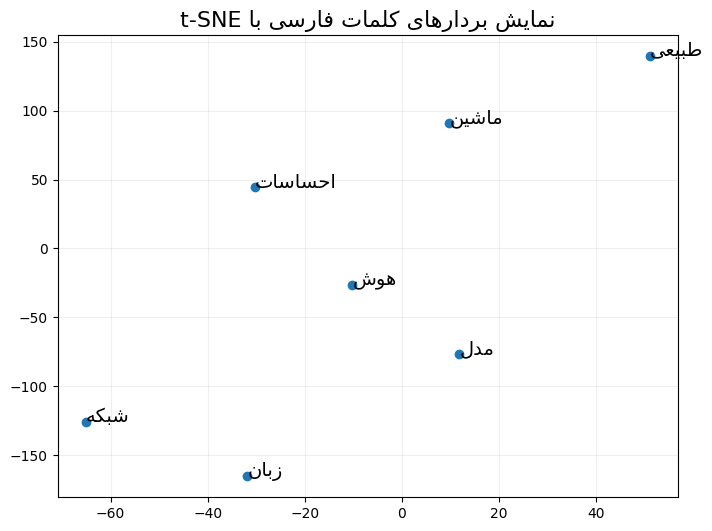

In [45]:
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt

selected = ["زبان", "هوش", "ماشین", "مدل", "شبکه", "احساسات", "طبیعی"]
vectors = np.array([model_sg.wv[w] for w in selected])

tsne = TSNE(n_components=2, random_state=42, perplexity=3)
reduced = tsne.fit_transform(vectors)

plt.figure(figsize=(8, 6))
plt.scatter(reduced[:, 0], reduced[:, 1])

for i, word in enumerate(selected):
    plt.annotate(
        fa(word),
        xy=(reduced[i, 0], reduced[i, 1]),
        fontsize=14
    )

plt.title(fa("نمایش بردارهای کلمات فارسی با t-SNE"), fontsize=16)
plt.grid(True, alpha=0.2)
plt.show()

In [46]:
model_sg.save("persian_word2vec.model")
loaded_model = Word2Vec.load("persian_word2vec.model")